# Laboratory 3  
## Phase Kickback, Deutsch–Jozsa, and Bernstein–Vazirani with PennyLane

Use the sections:

- **Task**
- **Hint**
- **Solution sketch**

Write your own code where requested, then compare with the solution sketch.

## Formulas

### Phase kickback
If $U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$,then $C\text{-}U\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}|\psi\rangle\right) = \left(\frac{|0\rangle+e^{2\pi i \theta}|1\rangle}{\sqrt{2}}\right)|\psi\rangle.$

### Phase oracle
If the ancilla is prepared in $|-\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}},$
then $U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle.$

This is the mechanism used in both Deutsch–Jozsa and Bernstein–Vazirani.

In [3]:
# Uncomment if PennyLane is not installed.
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 805.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 603.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 2.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 2.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.6 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 814.2 kB/s eta 0:00:00a 0:00:01


In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# Part A. Phase Kickback

## Task 1. CNOT as phase kickback

Prepare:

- the control qubit in $|+\rangle$;
- the target qubit in $|-\rangle$.

Then apply a CNOT gate and inspect the final state.

### What you should observe
Because $|-\rangle$ is an eigenstate of $X$ with eigenvalue $-1$, the phase should be kicked back onto the control qubit.

### Hint

Use: $|+\rangle = H|0\rangle,\qquad |-\rangle = H|1\rangle.$

So one reasonable preparation sequence is:

1. apply $H$ on wire 0;
2. apply $X$ then $H$ on wire 1;
3. apply `qml.CNOT(wires=[0,1])`;
4. return `qml.state()`.

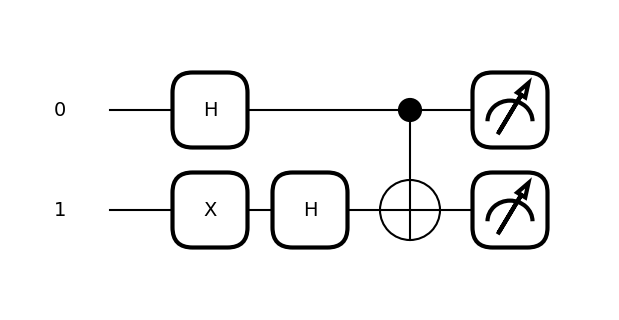

In [2]:
dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def cnot_kickback_student():
    # 1. prepare |+> on wire 0
    qml.Hadamard(wires=0)
    # 2. prepare |-> on wire 1
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    # 3. apply CNOT
    qml.CNOT(wires=[0, 1])

    # 4. return the state vector
    return qml.state()
# Run your circuit after filling it in.
cnot_kickback_student()
#Show the circuit diagram
fig, ax =qml.draw_mpl(cnot_kickback_student)()
plt.show()

### Solution sketch

The expected transformation is

$$
\frac{|0\rangle+|1\rangle}{\sqrt{2}}|-\rangle
\mapsto
\frac{|0\rangle-|1\rangle}{\sqrt{2}}|-\rangle
=
|-\rangle|-\rangle.
$$

So the control qubit picks up the phase $-1$.

In [3]:
@qml.qnode(dev2)
def cnot_kickback_solution():
    qml.Hadamard(wires=0)

    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)

    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    #return qml.state()
    return qml.probs(wires=0)

print("Probabilities for qubit 0:")
print(cnot_kickback_solution())


print("\nText drawing:")
print(qml.draw(cnot_kickback_solution)())

Probabilities for qubit 0:
[0. 1.]

Text drawing:
0: ──H────╭●──H─┤  Probs
1: ──X──H─╰X────┤       


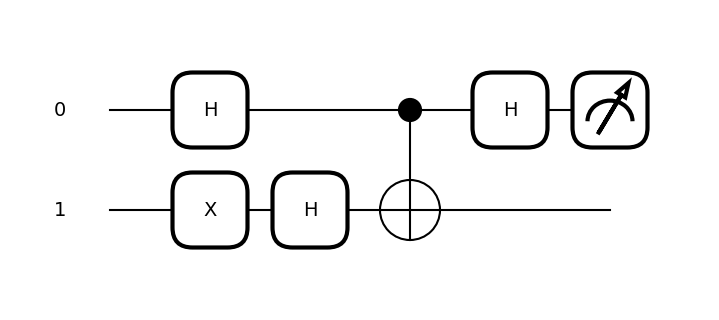

In [4]:
fig, ax = qml.draw_mpl(cnot_kickback_solution)()
plt.show()

## Task 2. Probabilities after a final Hadamard

Add a final Hadamard on the **control** qubit from Task 1 and return the measurement probabilities on wire 0.

### Question
What basis state do you measure with probability 1?

### Answer
1

### Hint

After kickback, the control qubit is

$$
|-\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

Then

$$
H|-\rangle = |1\rangle.
$$

In [13]:
@qml.qnode(dev2)
def cnot_kickback_with_final_h_student():
    # TODO:
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    # and return qml.probs(wires=0)
    return qml.probs(wires=0)

print(cnot_kickback_with_final_h_student())
print(qml.draw(cnot_kickback_with_final_h_student)())

[0. 1.]
0: ──H────╭●──H─┤  Probs
1: ──X──H─╰X────┤       


### Solution sketch

The final answer should be

$$
P(0)=0,\qquad P(1)=1.
$$

In [7]:
@qml.qnode(dev2)
def cnot_kickback_with_final_h_solution():
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

print(cnot_kickback_with_final_h_solution())

[0. 1.]


# Part B. Deutsch–Jozsa

## Minimal statement

We are given a Boolean function

$$
f:\{0,1\}^n \to \{0,1\}
$$

with the promise that it is either:

- **constant**, or
- **balanced**.

The Deutsch–Jozsa circuit decides which case holds using **one oracle call**.

## Task 3. Build simple Deutsch–Jozsa oracles

For $n=2$, implement the following:

1. a constant oracle for    $   f(x_0,x_1)=0; $
2. a constant oracle for    $   f(x_0,x_1)=1; $
3. a balanced oracle for    $   f(x_0,x_1)=x_0;$
4. a balanced oracle for   $   f(x_0,x_1)=x_0\oplus x_1.$

Use wire `n` as the ancilla.

### Hint

For an oracle of the form $|x\rangle|y\rangle \mapsto |x\rangle|y\oplus f(x)\rangle,$

you can implement:

- $f(x)=0$ by doing nothing;
- $f(x)=1$ by flipping the ancilla;
- $f(x)=x_0$ by one CNOT from wire 0 to the ancilla;
- $f(x)=x_0\oplus x_1$ by two CNOTs to the ancilla.

In [ ]:
def dj_oracle_constant_0(n):
    pass
def dj_oracle_constant_1(n):
    qml.PauliX(wires=n)

def dj_oracle_balanced_x0(n):
    qml.CNOT(wires=[0, n])

def dj_oracle_balanced_parity(n):
    for i in range(n):
        qml.CNOT(wires=[i, n])

### Solution sketch
A very direct implementation is enough here. 

In [14]:
def dj_oracle_constant_0_solution(n):
    pass

def dj_oracle_constant_1_solution(n):
    qml.PauliX(wires=n)

def dj_oracle_balanced_x0_solution(n):
    qml.CNOT(wires=[0, n])

def dj_oracle_balanced_parity_solution(n):
    for i in range(n):
        qml.CNOT(wires=[i, n])

## Task 4. Complete the Deutsch–Jozsa circuit

Fill in the circuit below.

For input size $n$, the algorithm is:

1. prepare $   |0\rangle^{\otimes n}|1\rangle;$
2. apply Hadamard to all qubits;
3. apply the oracle once;
4. apply Hadamard again to the first $n$ qubits;
5. measure the first $n$ qubits.

### Goal
Verify that:

- constant functions produce $  |00\cdots 0\rangle;$
- balanced functions do **not** produce $  |00\cdots 0\rangle.$

### Hint

Use `qml.probs(wires=range(n))`.

For $n=2$, the basis order is

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle.
$$

In [16]:
def deutsch_jozsa_student(n, oracle):
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        # TODO:
        # 1. prepare ancilla in |1>
        qml.PauliX(wires=n)
        # 2. apply H to all qubits
        for i in range(n + 1):
            qml.Hadamard(wires=i)
        # 3. apply oracle(n)
        oracle(n)
        # 4. apply H to first n qubits
        for i in range(n):
            qml.Hadamard(wires=i)
        # 5. return probabilities on the first n qubits
        return qml.probs(wires=range(n))

    return circuit()

# Example after filling:
print(deutsch_jozsa_student(2, dj_oracle_balanced_parity_solution))

[0. 0. 0. 1.]


### Solution sketch

The key identity is

$$
U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle.
$$

So the ancilla factors out, and the final Hadamards on the input register convert the phase pattern into a measurable bitstring.

In [19]:
def deutsch_jozsa_solution(n, oracle):
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        qml.PauliX(wires=n)

        for w in range(n + 1):
            qml.Hadamard(wires=w)

        oracle(n)

        for w in range(n):
            qml.Hadamard(wires=w)

        return qml.probs(wires=range(n))

    return circuit()

print("constant 0      :", deutsch_jozsa_solution(2, dj_oracle_constant_0_solution))
print("constant 1      :", deutsch_jozsa_solution(2, dj_oracle_constant_1_solution))
print("balanced x0     :", deutsch_jozsa_solution(2, dj_oracle_balanced_x0_solution))
print("balanced parity :", deutsch_jozsa_solution(2, dj_oracle_balanced_parity_solution))

constant 0      : [1. 0. 0. 0.]
constant 1      : [1. 0. 0. 0.]
balanced x0     : [0. 0. 1. 0.]
balanced parity : [0. 0. 0. 1.]


In [20]:
def deutsch_jozsa_circuit_for_draw(n, oracle):
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        qml.PauliX(wires=n)
        for w in range(n + 1):
            qml.Hadamard(wires=w)
        oracle(n)
        for w in range(n):
            qml.Hadamard(wires=w)
        return qml.probs(wires=range(n))

    return circuit

print(qml.draw(deutsch_jozsa_circuit_for_draw(2, dj_oracle_balanced_parity_solution))())

0: ──H────╭●──H────┤ ╭Probs
1: ──H────│──╭●──H─┤ ╰Probs
2: ──X──H─╰X─╰X────┤       


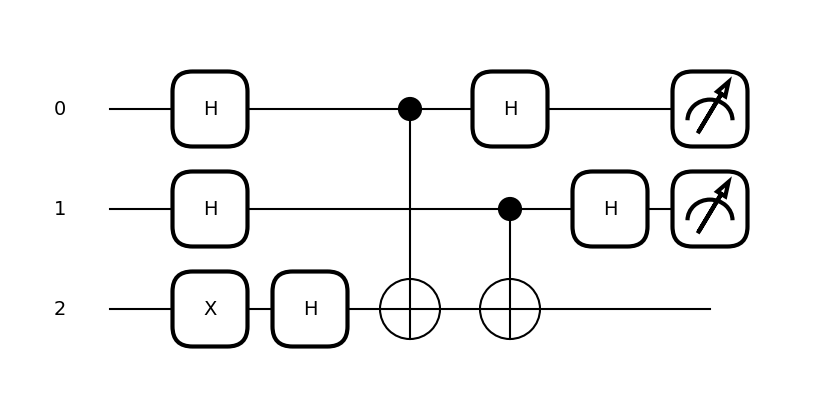

In [21]:
fig, ax = qml.draw_mpl(deutsch_jozsa_circuit_for_draw(2, dj_oracle_balanced_parity_solution))()
plt.show()

## Task 5. One more balanced oracle

For $n=3$, implement the balanced function

$$
f(x_0,x_1,x_2)=x_1.
$$

Run the Deutsch–Jozsa circuit and check that the output is not $|000\rangle.$

### Hint

Only one CNOT is needed, from wire 1 to the ancilla.

In [22]:
def dj_oracle_balanced_x1_student(n):
    # TODO
    pass

# After implementing:
# print(deutsch_jozsa_solution(3, dj_oracle_balanced_x1_student))

### Solution sketch
The oracle is balanced because half the inputs have $x_1=0$ and half have $x_1=1$.

In [23]:
def dj_oracle_balanced_x1_solution(n):
    qml.CNOT(wires=[1, n])

print(deutsch_jozsa_solution(3, dj_oracle_balanced_x1_solution))

[0. 0. 1. 0. 0. 0. 0. 0.]


# Part C. Bernstein–Vazirani

## Minimal statement

There is a hidden string

$$
s=s_0s_1\dots s_{n-1}\in\{0,1\}^n
$$

and the oracle computes

$$
f_s(x)=s\cdot x \pmod 2.
$$

The Bernstein–Vazirani algorithm recovers the entire string with **one oracle call**.

## Task 6. Build a Bernstein–Vazirani oracle

Implement an oracle generator for a secret bit string such as

$$
s=101.
$$

Use the rule:

- if $s_i=1$, add a CNOT from input wire $i$ to the ancilla;
- if $s_i=0$, do nothing.

### Hint

If the secret is `[1,0,1]`, the oracle should apply:

- CNOT from wire 0 to ancilla,
- no gate from wire 1,
- CNOT from wire 2 to ancilla.

In [24]:
def bv_oracle_student(secret_bits):
    # TODO
    pass

### Solution sketch

This is one of the nicest quantum oracles because the implementation is almost direct.

In [25]:
def bv_oracle_solution(secret_bits):
    n = len(secret_bits)
    for i, bit in enumerate(secret_bits):
        if bit == 1:
            qml.CNOT(wires=[i, n])

## Task 7. Complete the Bernstein–Vazirani circuit

Fill in the missing parts and verify that the measured output matches the secret string.

### Goal
For a secret such as

$$
s=101,
$$

the output distribution should be concentrated on

$$
|101\rangle.
$$

### Hint

The circuit structure is almost the same as Deutsch–Jozsa:

1. prepare
   $$
   |0\rangle^{\otimes n}|1\rangle;
   $$
2. apply Hadamard to all qubits;
3. apply the oracle;
4. apply Hadamard again to the first $n$ qubits;
5. measure the first $n$ qubits.

In [26]:
def bernstein_vazirani_student(secret_bits):
    n = len(secret_bits)
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        # TODO
        pass

    return circuit()

# Example:
# print(bernstein_vazirani_student([1,0,1]))

### Solution sketch

After the oracle, the input register contains the phase pattern

$$
\frac{1}{\sqrt{2^n}}\sum_x (-1)^{s\cdot x}|x\rangle.
$$

The final Hadamards convert this state exactly into

$$
|s\rangle.
$$

In [27]:
def bernstein_vazirani_solution(secret_bits):
    n = len(secret_bits)
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        qml.PauliX(wires=n)

        for w in range(n + 1):
            qml.Hadamard(wires=w)

        bv_oracle_solution(secret_bits)

        for w in range(n):
            qml.Hadamard(wires=w)

        return qml.probs(wires=range(n))

    return circuit()

for secret in ([1,0,1], [0,1,1], [1,1,1], [0,0,0]):
    print(f"{secret} -> {bernstein_vazirani_solution(secret)}")

[1, 0, 1] -> [0. 0. 0. 0. 0. 1. 0. 0.]
[0, 1, 1] -> [0. 0. 0. 1. 0. 0. 0. 0.]
[1, 1, 1] -> [0. 0. 0. 0. 0. 0. 0. 1.]
[0, 0, 0] -> [1. 0. 0. 0. 0. 0. 0. 0.]


In [28]:
def bv_circuit_for_draw(secret_bits):
    n = len(secret_bits)
    dev = qml.device("default.qubit", wires=n + 1)

    @qml.qnode(dev)
    def circuit():
        qml.PauliX(wires=n)
        for w in range(n + 1):
            qml.Hadamard(wires=w)
        bv_oracle_solution(secret_bits)
        for w in range(n):
            qml.Hadamard(wires=w)
        return qml.probs(wires=range(n))

    return circuit

print(qml.draw(bv_circuit_for_draw([1,0,1]))())

0: ──H────╭●──H────┤ ╭Probs
1: ──H────│───H────┤ ├Probs
2: ──H────│──╭●──H─┤ ╰Probs
3: ──X──H─╰X─╰X────┤       


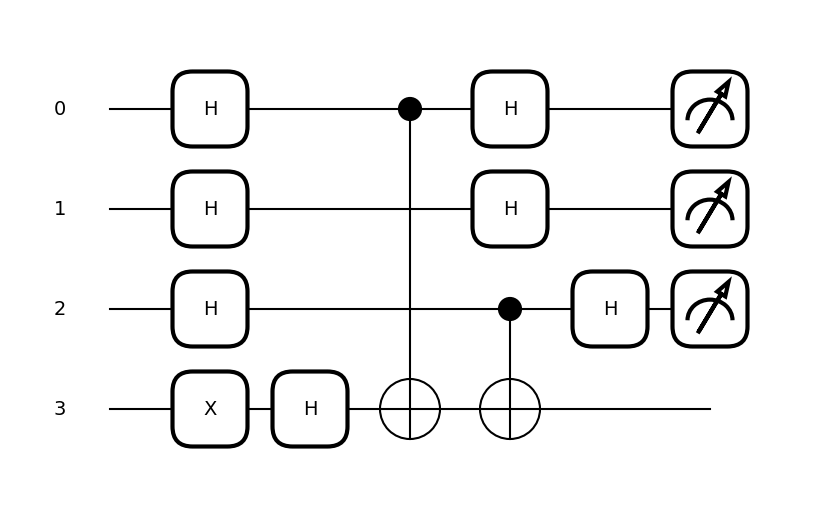

In [29]:
fig, ax = qml.draw_mpl(bv_circuit_for_draw([1,0,1]))()
plt.show()

## Task 8. Secret string practice

Run the Bernstein–Vazirani circuit for the following secrets: $001,\quad 010,\quad 101,\quad 111.$

Record the observed output bitstring in each case.

### Hint

For $n=3$, the basis order is

$$
|000\rangle, |001\rangle, |010\rangle, |011\rangle, |100\rangle, |101\rangle, |110\rangle, |111\rangle.
$$

So you should look for the position of the entry equal to 1.

In [30]:
test_secrets = [
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
    [1, 1, 1],
]

for secret in test_secrets:
    print(secret, "->", bernstein_vazirani_solution(secret))

[0, 0, 1] -> [0. 1. 0. 0. 0. 0. 0. 0.]
[0, 1, 0] -> [0. 0. 1. 0. 0. 0. 0. 0.]
[1, 0, 1] -> [0. 0. 0. 0. 0. 1. 0. 0.]
[1, 1, 1] -> [0. 0. 0. 0. 0. 0. 0. 1.]


### Solution sketch

Each run should return the secret string itself.  
That is the whole point of the algorithm, and also why it annoys classical query complexity.

# Short reflection questions

## Task 9
Explain in 3 to 5 lines why the ancilla can be ignored after the oracle call in both Deutsch–Jozsa and Bernstein–Vazirani.

### Hint

Use

$$
U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle.
$$

### Solution sketch

The ancilla returns to the same state $|-\rangle$ for every input $x$.  
Only the phase factor depends on $f(x)$.  
Therefore the ancilla factors out and all useful information is stored in the phase pattern of the input register.

## Task 10
Suppose the target is **not** an eigenstate of $U$. Explain why clean phase kickback fails.

### Hint

Write

$$
|\phi\rangle = \sum_j c_j |\psi_j\rangle
$$

in an eigenbasis of $U$.

### Solution sketch

If

$$
U|\psi_j\rangle = e^{2\pi i \theta_j}|\psi_j\rangle,
$$

then after controlled-$U$ the state becomes

$$
\frac{1}{\sqrt{2}}\sum_j c_j\left(|0\rangle + e^{2\pi i \theta_j}|1\rangle\right)|\psi_j\rangle.
$$

Now the control and target are entangled, so there is no single phase factor to extract.

# Optional workspace
Use the next cell for your own tests.

In [ ]:
# Your experiments here
# Example:
# print(deutsch_jozsa_solution(3, dj_oracle_balanced_x1_solution))
# print(bernstein_vazirani_solution([1, 0, 0, 1]))